1.  **Importar Herramientas:** Se cargan las librerías necesarias: **`pandas`** para manejar la tabla de datos, **`tensorflow`** y **`keras`** para construir y gestionar la Red Neuronal, y varios módulos de **`sklearn`** para las tareas de preprocesamiento (escalado, división de datos) y evaluación.
2.  **Cargar la Tabla:** Se lee el archivo **`datasetwifis.csv`** (el dataset limpio, pivoteado y listo) y se guarda en la tabla principal llamada `df`.
3.  **Verificación:** Se comprueba que los datos (las 651 filas de lecturas y las 112 columnas de BSSids y ubicación) se hayan cargado sin problemas.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Configuración para evitar notación científica en numpy
np.set_printoptions(suppress=True, precision=4)

# Cargar el dataset
data_path = '/content/drive/MyDrive/Archivos .csv/datasetwifis.csv'
df = pd.read_csv(data_path)

# Mostrar las primeras filas y la información del dataset
print("DataFrame Original")
print(df.head())
print("\nInformación del DataFrame")
df.info()

DataFrame Original
   Unnamed: 0  Lect  00:01:33:88:20:54  00:0f:66:e9:ab:ec  04:f0:21:63:18:b2  \
0           0     1                0.0                0.0                0.0   
1           1     2                0.0                0.0                0.0   
2           2     3                0.0                0.0                0.0   
3           3     4                0.0                0.0                0.0   
4           4     5                0.0                0.0                0.0   

   26:39:4e:c8:ed:3c  26:60:b6:4d:5c:fc  28:77:77:dc:3d:68  28:77:77:dc:3d:a9  \
0                0.0                0.0                0.0                0.0   
1                0.0                0.0                0.0                0.0   
2              -91.0                0.0                0.0                0.0   
3              -91.0                0.0                0.0                0.0   
4              -91.0                0.0                0.0                0.0   

   2a:77:77:c

In [11]:
# Definimos las columnas que NO son características (MAC addresses)
cols_to_drop = ['Ubicacion', 'Unnamed: 0', 'Lect']

# Eliminamos esas columnas y reemplazamos 0.0 por -100
# errors='ignore' evita el error si alguna columna ya no existe
df_features = df.drop(columns=cols_to_drop, errors='ignore').replace(0.0, -100)

# Verificación rápida
print("Columnas restantes:", df_features.shape[1])
print(df_features.head())

Columnas restantes: 109
   00:01:33:88:20:54  00:0f:66:e9:ab:ec  04:f0:21:63:18:b2  26:39:4e:c8:ed:3c  \
0             -100.0             -100.0             -100.0             -100.0   
1             -100.0             -100.0             -100.0             -100.0   
2             -100.0             -100.0             -100.0              -91.0   
3             -100.0             -100.0             -100.0              -91.0   
4             -100.0             -100.0             -100.0              -91.0   

   26:60:b6:4d:5c:fc  28:77:77:dc:3d:68  28:77:77:dc:3d:a9  2a:77:77:cc:3d:a9  \
0             -100.0             -100.0             -100.0             -100.0   
1             -100.0             -100.0             -100.0             -100.0   
2             -100.0             -100.0             -100.0             -100.0   
3             -100.0             -100.0             -100.0             -100.0   
4             -100.0             -100.0             -100.0             -100.0   

  

In [12]:
# Estandarización
X_scaled = StandardScaler().fit_transform(df_features)

# Aplicación de PCA
pca = PCA(n_components=0.95) # Conservamos el 95% de varianza
X_pca = pca.fit_transform(X_scaled)

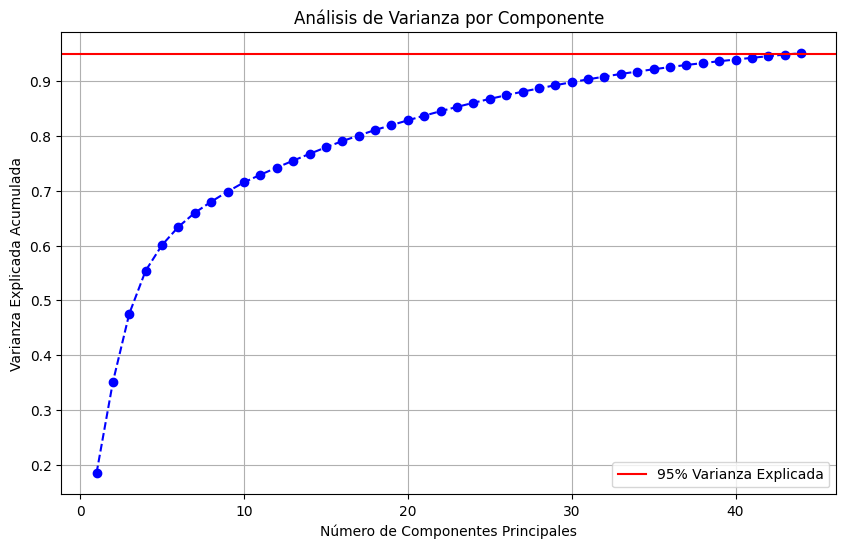

In [13]:
# Calculamos la varianza acumulada
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Creamos el gráfico
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')

# Línea de referencia del 95%
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Varianza Explicada')

plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Análisis de Varianza por Componente')
plt.legend()
plt.grid(True)
plt.show()

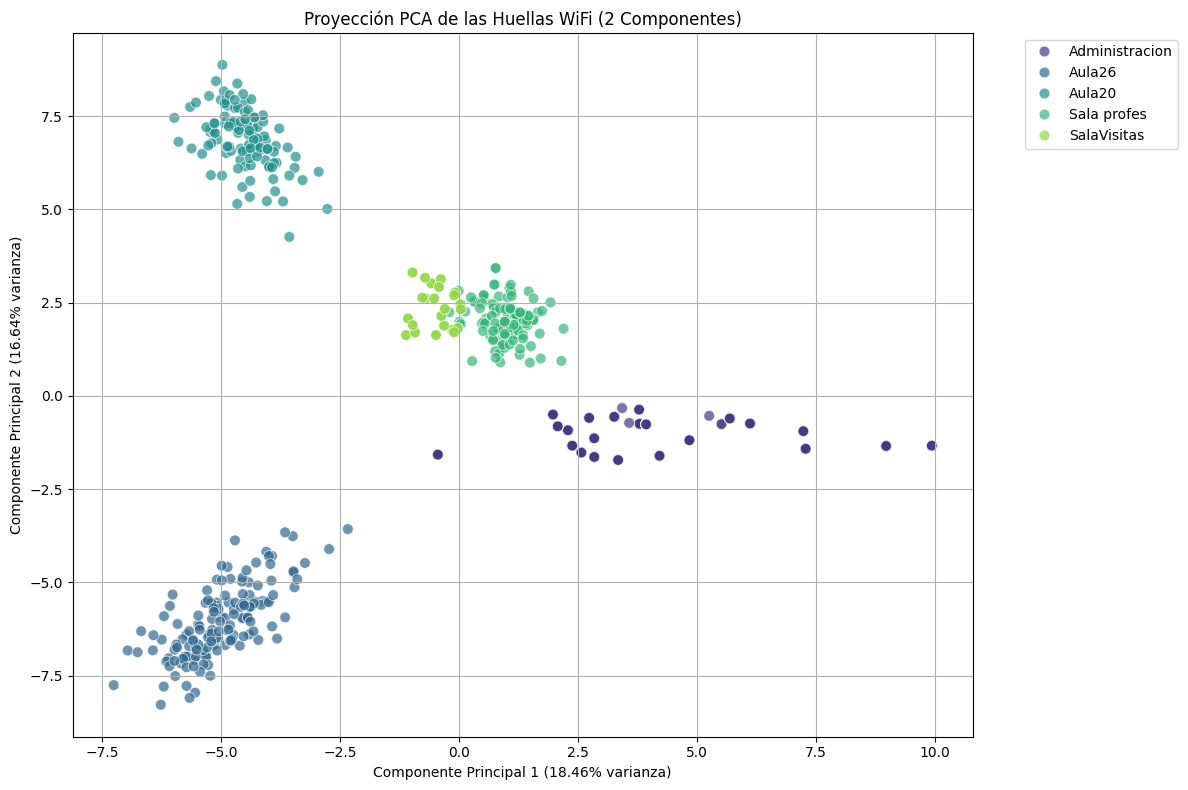

In [14]:
# Creamos un DataFrame temporal con los 2 primeros componentes y la etiqueta
# Asumiendo que 'X_pca' es el resultado del PCA y 'df' es la tabla original con la columna 'Ubicacion'
df_pca_2d = pd.DataFrame(data=X_pca[:, :2], columns=['PC1', 'PC2'])
df_pca_2d['Ubicacion'] = df['Ubicacion'].values

# Creamos el gráfico de dispersión
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Ubicacion',    # Colorea los puntos según la ubicación
    data=df_pca_2d,
    palette='viridis',  # Paleta de colores
    s=60,               # Tamaño de los puntos
    alpha=0.7           # Transparencia para ver puntos superpuestos
)

plt.title('Proyección PCA de las Huellas WiFi (2 Componentes)')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.2%} varianza)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.2%} varianza)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Mueve la leyenda fuera del gráfico si son muchas etiquetas
plt.grid(True)
plt.tight_layout()
plt.show()